### Logistic Regression Classifier

### Import necessary libraries and reading the desired dataset

In [1]:
# Import necessary Python libraries
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


### Set working directory

In [4]:
os.getcwd() # Get current working directory

'C:\\Users\\tmollick\\Documents\\iMapML\\Code'

In [6]:
os.chdir(r"C:\Users\tmollick\Documents\iMapML\Datasets") # Change current working directory
os.listdir() # Check new files in the new directory

['11 Species.xlsx',
 '14 Invasive Species.xlsx',
 '14 Species for Taxon ID and jurisdiction species ID.xlsx',
 'Beech_leaf_disease_nematode_100_records.xlsx',
 'Common_Buckthorn_100_records.xlsx',
 'Confirmed_Honeysuckles_141_records.xlsx',
 'Confirmed_Phragmites_145_records.xlsx',
 'Confirmed_Wild_Parsnip_140_records.xlsx',
 'Garlic Mustard 100 records.xlsx',
 'Hemlock Woolly Adelgid_100_records.xlsx',
 'Japanese Knotweed 100 records.xlsx',
 'Japanese_Barberry_100_records.xlsx',
 'Multiflora Rose 100 records.xlsx',
 'Oriental_Bittersweet_100_records.xlsx',
 'Purple_Loosestrife_100_records.xlsx',
 'Spotted Lanternfly 100 records.xlsx',
 'Tree-of-heaven 100 records.xlsx']

In [8]:
# Define the output path
output_path = r"C:\Users\tmollick\Documents\iMapML\Figures"

In [10]:
# Construct the full file path
#file_path = os.path.join(directory, filename)

df = pd.read_excel("Garlic Mustard 100 records.xlsx", engine="openpyxl")  # Use 'openpyxl' for .xlsx files

### Data preprocessing

In [13]:
# Convert 'com_score' to numeric, setting non-numeric values to NaN
df["com_score"] = pd.to_numeric(df["com_score"], errors='coerce')
df["geo_score"] = pd.to_numeric(df["geo_score"], errors='coerce')
df.head()

,S.L.,imaplink,presenceId,presentSpeciesId,iMapPhoto,imap_sci,imap_com,imap_record_taxon,inatlink,inat_sci,...,inat_taxon,geo_score,com_score,visual_model,species_label,com_status,Verification,Photo_quality,Notes,Comments
0,1,View,1013891,1014154,View,Alliaria petiolata,Garlic Mustard,56061,View,Alliaria petiolata,...,56061,18.86,97.61,1,1,NaN,Both iMap and iNat correct,Good photo,NaN,NaN
1,2,View,1013410,1013556,View,Alliaria petiolata,Garlic Mustard,56061,View,Alliaria petiolata,...,56061,46.51,99.78,1,1,NaN,Both iMap and iNat correct,Good photo,NaN,NaN
2,3,View,532728,532728,View,Alliaria petiolata,Garlic Mustard,56061,View,Alliaria petiolata,...,56061,42.62,99.55,1,1,NaN,Both iMap and iNat correct,Good photo,NaN,NaN
3,4,View,1332167,1345926,View,Alliaria petiolata,Garlic Mustard,56061,View,Alliaria petiolata,...,56061,51.26,74.63,1,1,NaN,Both iMap and iNat correct,Good photo,NaN,NaN
4,5,View,1435896,1449649,View,Alliaria petiolata,Garlic Mustard,56061,View,Alliaria petiolata,...,56061,69.93,19.23,1,1,NaN,Both iMap and iNat correct,Bad-Blur Photo,NaN,NaN


In [15]:
df.shape

(100, 21)

In [17]:
df.columns

Index(['S.L.', 'imaplink', 'presenceId', 'presentSpeciesId', 'iMapPhoto',
       'imap_sci', 'imap_com', 'imap_record_taxon', 'inatlink', 'inat_sci',
       'inat_com', 'inat_taxon', 'geo_score', 'com_score', 'visual_model',
       'species_label', 'com_status', 'Verification', 'Photo_quality', 'Notes',
       'Comments'],
      dtype='object')

In [19]:
# find categorical variables

categorical = [var for var in df.columns if df[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :', categorical)

There are 10 categorical variables

The categorical variables are : ['imaplink', 'iMapPhoto', 'imap_sci', 'imap_com', 'inatlink', 'inat_sci', 'inat_com', 'Verification', 'Photo_quality', 'Comments']


In [21]:
df[categorical].head()

,imaplink,iMapPhoto,imap_sci,imap_com,inatlink,inat_sci,inat_com,Verification,Photo_quality,Comments
0,View,View,Alliaria petiolata,Garlic Mustard,View,Alliaria petiolata,Garlic mustard,Both iMap and iNat correct,Good photo,NaN
1,View,View,Alliaria petiolata,Garlic Mustard,View,Alliaria petiolata,Garlic mustard,Both iMap and iNat correct,Good photo,NaN
2,View,View,Alliaria petiolata,Garlic Mustard,View,Alliaria petiolata,Garlic mustard,Both iMap and iNat correct,Good photo,NaN
3,View,View,Alliaria petiolata,Garlic Mustard,View,Alliaria petiolata,Garlic mustard,Both iMap and iNat correct,Good photo,NaN
4,View,View,Alliaria petiolata,Garlic Mustard,View,Alliaria petiolata,Garlic mustard,Both iMap and iNat correct,Bad-Blur Photo,NaN


In [23]:
df.isnull().sum()

S.L.                   0
imaplink               0
presenceId             0
presentSpeciesId       0
iMapPhoto              0
imap_sci               0
imap_com               0
imap_record_taxon      0
inatlink               0
inat_sci               0
inat_com               0
inat_taxon             0
geo_score              0
com_score              0
visual_model           0
species_label          0
com_status           100
Verification           0
Photo_quality          0
Notes                100
Comments              78
dtype: int64

In [25]:
df.describe()

,S.L.,presenceId,presentSpeciesId,imap_record_taxon,inat_taxon,geo_score,com_score,visual_model,species_label,com_status,Notes
count,100.000000,1.000000e+02,1.000000e+02,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,0.0,0.0
mean,50.500000,9.714222e+05,9.772842e+05,56061.0,81630.780000,39.895700,67.962700,0.810000,0.770000,NaN,NaN
std,29.011492,3.721872e+05,3.772441e+05,0.0,117732.689842,22.272111,34.700572,0.394277,0.422953,NaN,NaN
min,1.000000,3.291820e+05,3.291820e+05,56061.0,890.000000,0.000000,5.120000,0.000000,0.000000,NaN,NaN
25%,25.750000,5.223728e+05,5.223728e+05,56061.0,56061.000000,22.530000,33.682500,1.000000,1.000000,NaN,NaN
50%,50.500000,1.062046e+06,1.066610e+06,56061.0,56061.000000,41.030000,86.970000,1.000000,1.000000,NaN,NaN
75%,75.250000,1.282974e+06,1.292476e+06,56061.0,56061.000000,50.105000,98.760000,1.000000,1.000000,NaN,NaN
max,100.000000,1.443061e+06,1.457678e+06,56061.0,971907.000000,90.870000,99.970000,1.000000,1.000000,NaN,NaN


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.L.               100 non-null    int64  
 1   imaplink           100 non-null    object 
 2   presenceId         100 non-null    int64  
 3   presentSpeciesId   100 non-null    int64  
 4   iMapPhoto          100 non-null    object 
 5   imap_sci           100 non-null    object 
 6   imap_com           100 non-null    object 
 7   imap_record_taxon  100 non-null    int64  
 8   inatlink           100 non-null    object 
 9   inat_sci           100 non-null    object 
 10  inat_com           100 non-null    object 
 11  inat_taxon         100 non-null    int64  
 12  geo_score          100 non-null    float64
 13  com_score          100 non-null    float64
 14  visual_model       100 non-null    int64  
 15  species_label      100 non-null    int64  
 16  com_status         0 non-nu

### See the spread of combined and geo score

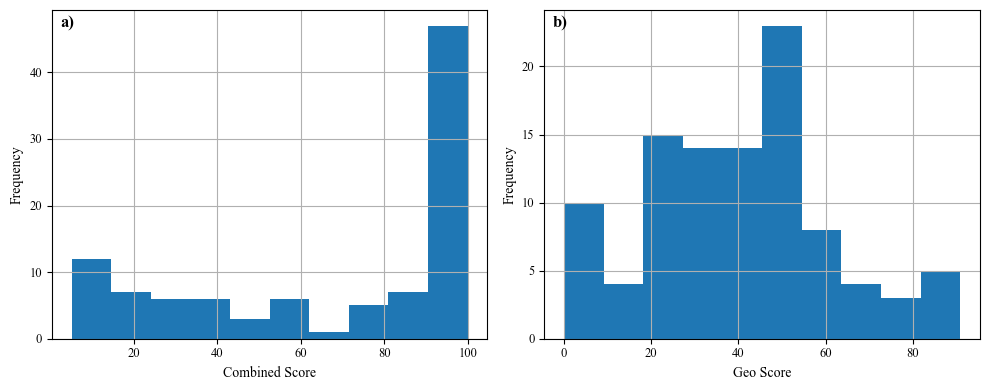

In [30]:
# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Plot histograms with improved formatting
plt.figure(figsize=(10, 4))

# Histogram for Combined Score
plt.subplot(1, 2, 1)
fig = df.com_score.hist(bins=10)  
plt.xlabel('Combined Score', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.text(0.02, 0.95, 'a)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold')

# Histogram for Geo Score
plt.subplot(1, 2, 2)
fig = df.geo_score.hist(bins=10) 
plt.xlabel('Geo Score', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.text(0.02, 0.95, 'b)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold')

# Adjust layout
plt.tight_layout()

# Save the plot (use the correct output_path)
# output_file = os.path.join(output_path, "Spread of combined and geo score.png")
# plt.savefig(output_file, dpi=300, bbox_inches="tight")

# Show the plot
plt.show()


In [32]:
df[["com_score", "geo_score"]].describe()

,com_score,geo_score
count,100.000000,100.000000
mean,67.962700,39.895700
std,34.700572,22.272111
min,5.120000,0.000000
25%,33.682500,22.530000
50%,86.970000,41.030000
75%,98.760000,50.105000
max,99.970000,90.870000


In [34]:
# Replace Outliers of com_score with Mean
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df["com_score"].quantile(0.25)
Q3 = df["com_score"].quantile(0.75)

# Compute Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Compute the mean of the column
mean_value = df["com_score"].mean()

# Replace outliers with the mean value
df["com_score"] = np.where((df["com_score"] < lower_bound) | (df["com_score"] > upper_bound), mean_value, df["com_score"])

In [36]:
df[["com_score", "geo_score"]].describe()

,com_score,geo_score
count,100.000000,100.000000
mean,67.962700,39.895700
std,34.700572,22.272111
min,5.120000,0.000000
25%,33.682500,22.530000
50%,86.970000,41.030000
75%,98.760000,50.105000
max,99.970000,90.870000


In [38]:
# Convert 'Photo_quality' to binary values
#df['Photo_quality_binary'] = df['Photo_quality'].apply(lambda x: 1 if x == 'Good photo' else 0)
#df.head()
Photo_mapping = {
    'Bad-Blur Photo': 0,
    'Bad-Dried Stems': 1,
    'Bad-limited contrast': 2,
    'Bad-Photo taken from long distance': 3,
    'Bad-Multiple focused species': 4,
    'Bad-Focused Different Species': 5,
    'Good photo': 6,
}

# Create new column 'Verification_numeric' with mapped values
df['Photo_quality_binary'] = df['Photo_quality'].map(Photo_mapping)

In [40]:
df['Photo_quality_binary'].isnull().sum()

0

In [42]:
# Perform statistical analysis
stats_df = df.groupby('Photo_quality')['com_score'].agg(['min', 'mean', 'median', 'max', 'std', 'count'])
stats_df

,min,mean,median,max,std,count
Photo_quality,,,,,,
Bad-Blur Photo,11.92,45.226250,35.905,86.94,30.558885,8
Bad-Dried Stems,6.10,28.224545,14.330,98.75,29.140067,11
Bad-Focused Different Species,5.12,29.510000,29.510,53.90,34.492669,2
Bad-Multiple focused species,38.76,38.760000,38.760,38.76,NaN,1
Bad-Photo taken from long distance,5.63,28.407692,25.240,60.05,17.549466,13
Bad-limited contrast,13.25,52.394545,49.470,96.44,30.320044,11
Good photo,54.25,94.084630,98.345,99.97,9.647529,54


### Box plots of combined score and photo quality

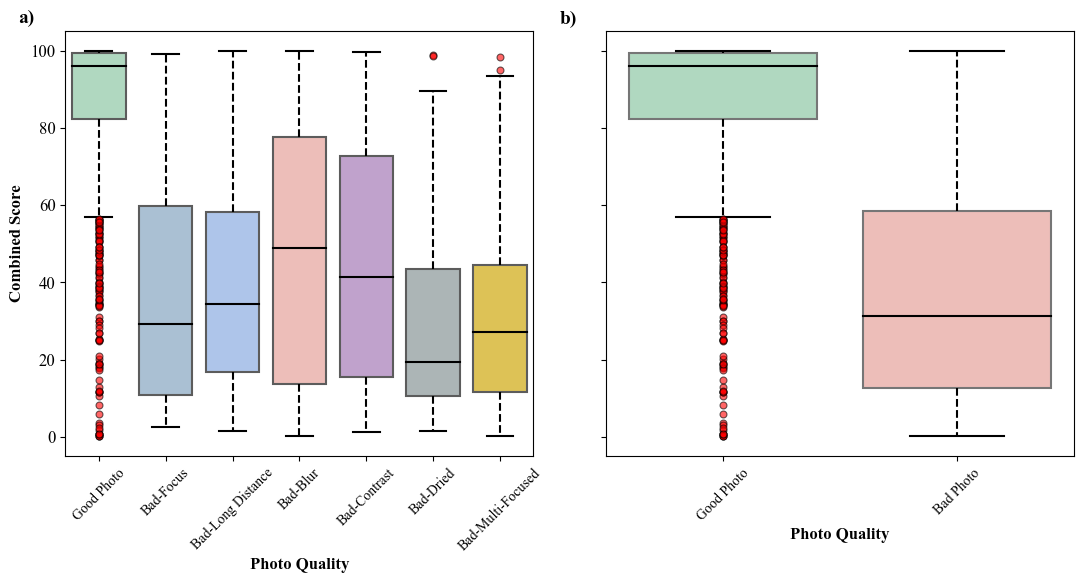

In [433]:
# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Create the figure with 2 subplots in 1 row
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)

# Define custom flier (outlier) appearance: red fill, black edge
flier_style = dict(
    marker='o',
    markersize=5,
    markerfacecolor='red',
    markeredgecolor='black',  # <-- Black border
    markeredgewidth=0.8,
    alpha=0.6,
    linestyle='none'
)

# -------- First subplot: Multi-category Photo_quality --------
sns.boxplot(
    ax=axes[0],
    x='Photo_quality', 
    y='com_score', 
    data=df,
    palette=['#A9DFBF', '#A3C1DA', '#a4c2f4', '#F5B7B1', '#C39BD3', '#AAB7B8', '#F4D03F'],
    whiskerprops=dict(color='black', linestyle='dashed'),
    capprops=dict(color='black'),
    medianprops=dict(color='black'),
    flierprops=flier_style
)

# Custom x-tick labels for first plot
short_labels1 = ['Good Photo', 'Bad-Focus', 'Bad-Long Distance', 'Bad-Blur', 'Bad-Contrast', 'Bad-Dried', 'Bad-Multi-Focused']
axes[0].set_xticks(range(len(short_labels1)))
axes[0].set_xticklabels(short_labels1, rotation=45, fontsize=10)
axes[0].set_xlabel('Photo Quality', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Combined Score', fontsize=12, fontweight='bold')

# Label subplot "a)" in the upper-left outside corner
axes[0].text(-0.10, 1.02, 'a)', transform=axes[0].transAxes, fontsize=14, fontweight='bold')

# -------- Second subplot: Good vs Bad Photo_GB --------
sns.boxplot(
    ax=axes[1],
    x='Photo_GB', 
    y='com_score', 
    data=df,
    palette=['#A9DFBF', '#F5B7B1'],
    whiskerprops=dict(color='black', linestyle='dashed'),
    capprops=dict(color='black'),
    medianprops=dict(color='black'),
    flierprops=flier_style
)

# Custom x-tick labels for second plot
short_labels2 = ['Good Photo', 'Bad Photo']
axes[1].set_xticks(range(len(short_labels2)))
axes[1].set_xticklabels(short_labels2, rotation=45, fontsize=10)
axes[1].set_xlabel('Photo Quality', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')  # Avoid repeating y-label

# Label subplot "b)" in the upper-left outside corner
axes[1].text(-0.10, 1.02, 'b)', transform=axes[1].transAxes, fontsize=14, fontweight='bold')

# Adjust layout
plt.tight_layout()

# Save combined figure
output_file = os.path.join(output_path, "Subplot_Boxplot_PhotoQuality_Combined.png")
plt.savefig(output_file, dpi=300, bbox_inches="tight")

# Show the combined plot
plt.show()


### Logistic Regression

### Assumptions of Logistic Regression

The Logistic Regression model requires several key assumptions. These are as follows:-

1. Logistic Regression model requires the dependent variable to be binary, multinomial or ordinal in nature.

2. It requires the observations to be independent of each other. So, the observations should not come from repeated measurements.

3. Logistic Regression algorithm requires little or no multicollinearity among the independent variables. It means that the independent variables should not be too highly correlated with each other.

4. Logistic Regression model assumes linearity of independent variables and log odds.

5. The success of Logistic Regression model depends on the sample sizes. Typically, it requires a large sample size to achieve the high accuracy.

In [44]:
# Declare feature vector and target variable
X = df[['com_score', 'geo_score', 'Photo_quality_binary']]

y = df['species_label']

In [46]:
# Split data into separate training and test set 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [48]:
# check the shape of X_train and X_test
X_train.shape, X_test.shape

((80, 3), (20, 3))

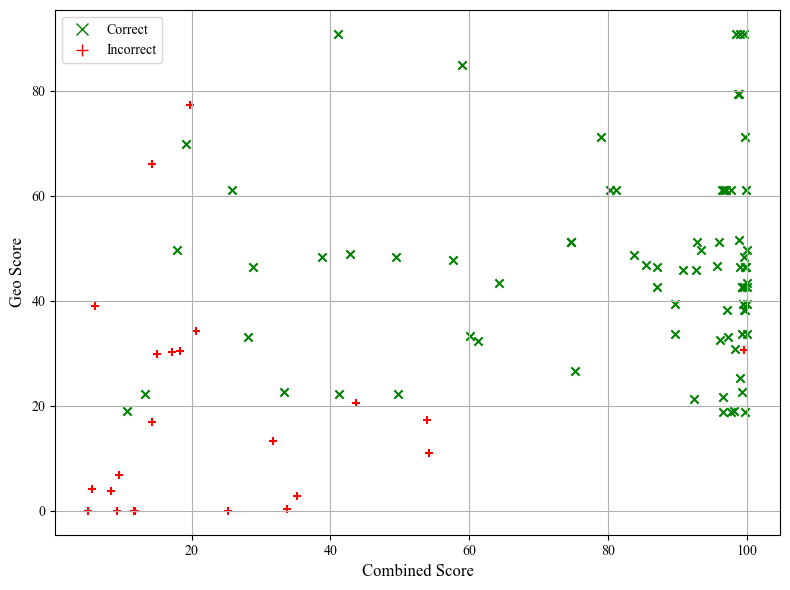

In [50]:
# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Plot data points function
def plot_points(xy, labels):
    # Define markers and colors
    markers = ['+', 'x', '.']
    colors = ['red', 'green', 'blue']

    # Convert labels to numpy array if it's not already
    labels = labels.to_numpy() if hasattr(labels, "to_numpy") else labels

    # Create scatter plots for each label
    for i, label in enumerate(set(labels)):
        # Extract points for this label
        points = np.array([xy[j, :] for j in range(len(xy)) if labels[j] == label])
        marker = markers[i % len(markers)]
        color = colors[i % len(colors)]

        # Plot points
        plt.scatter(points[:, 0], points[:, 1], marker=marker, color=color, label=f'Class {label}')

# Plot the data
plt.figure(figsize=(8, 6))

# Convert X_train to NumPy array before plotting
plot_points(X.values, y)

# Labels and title
plt.xlabel('Combined Score', fontsize=12)
plt.ylabel('Geo Score', fontsize=12)
# plt.title('Feature Distribution', fontsize=14)

# Add custom legend mapping
custom_handles = [
    plt.Line2D([0], [0], marker='x', color='green', linestyle='None', markersize=8, label='Correct'),
    plt.Line2D([0], [0], marker='+', color='red', linestyle='None', markersize=8, label='Incorrect')
]

plt.legend(handles=custom_handles, loc='upper left', fontsize=10)

# Grid and layout
plt.grid(True)
plt.tight_layout()

output_file = os.path.join(output_path, "Scatter plot of correct vs incorrect identification.png")
plt.savefig(output_file, dpi=300, bbox_inches="tight")

# Show plot
plt.show()


### Model training

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for C values
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Initialize Logistic Regression
logreg = LogisticRegression(solver='liblinear')

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print the best C value
print(f"Best C value: {grid_search.best_params_['C']}")
print(f"Best accuracy: {grid_search.best_score_:.4f}")

Best C value: 10
Best accuracy: 0.9125


In [54]:
# Train a logistic regression model
log_reg = LogisticRegression(C=100, solver='liblinear', random_state=0)
log_reg.fit(X_train, y_train)

# Predict probabilities
y_probs = log_reg.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

### Predict results

In [56]:
y_pred_test = log_reg.predict(X_test)

y_pred_test

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1],
      dtype=int64)

In [57]:
# probability of getting output as 0 - Incorrect identification

log_reg.predict_proba(X_test)[:,0][0:10, ] # Showing the first 10 values

array([0.93343166, 0.00514375, 0.01036169, 0.00942618, 0.04306011,
       0.00486913, 0.00989019, 0.10635968, 0.16545884, 0.04496971])

In [58]:
# probability of getting output as 1 - Correct identification

log_reg.predict_proba(X_test)[:,1][0:10, ] # Showing the first 10 values

array([0.06656834, 0.99485625, 0.98963831, 0.99057382, 0.95693989,
       0.99513087, 0.99010981, 0.89364032, 0.83454116, 0.95503029])

### Check accuracy score 

In [60]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

Model accuracy score: 0.9500


### Compare the train-set and test-set accuracy

In [62]:
y_pred_train = log_reg.predict(X_train)

y_pred_train

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1], dtype=int64)

In [63]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.9250


In [64]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(log_reg.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(log_reg.score(X_test, y_test)))

Training set score: 0.9250
Test set score: 0.9500


In [65]:
# check class distribution in test set
y_test.value_counts()


1    17
0     3
Name: species_label, dtype: int64

### Confusion Matrix

In [77]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

print('Confusion matrix\n\n', cm)

print('\nTrue Negatives(TN) = ', cm[0,0])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives (FN) = ', cm[1,0])

print('\nTrue Positives (TP) = ', cm[1,1])

Confusion matrix

 [[ 2  1]
 [ 0 17]]

True Negatives(TN) =  2

False Positives(FP) =  1

False Negatives (FN) =  0

True Positives (TP) =  17


Four types of outcomes are possible while evaluating a classification model performance. These four outcomes are described below:-

1. True Positives (TP) – True Positives occur when we predict an observation belongs to a certain class and the observation actually belongs to that class.

2. True Negatives (TN) – True Negatives occur when we predict an observation does not belong to a certain class and the observation actually does not belong to that class.

3. False Positives (FP) – False Positives occur when we predict an observation belongs to a certain class but the observation actually does not belong to that class. This type of error is called Type I error.

4. False Negatives (FN) – False Negatives occur when we predict an observation does not belong to a certain class but the observation actually belongs to that class. This is a very serious error and it is called Type II error.

1. True Positives (Actual Positive:1 and Predict Positive:1) - 175
2. True Negatives (Actual Negative:0 and Predict Negative:0) - 16
3. False Positives (Actual Negative:0 but Predict Positive:1) - 22 (Type I error)
4. False Negatives (Actual Positive:1 but Predict Negative:0) - 7 (Type II error)

<AxesSubplot: >

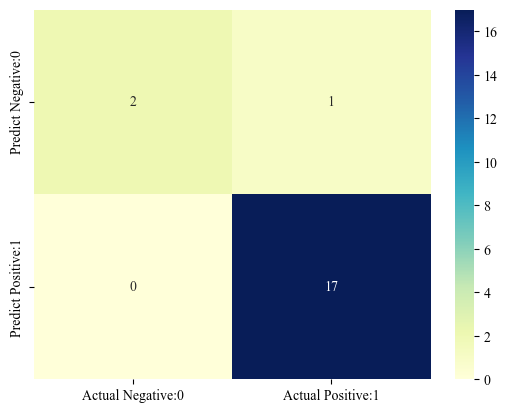

In [81]:
# visualize confusion matrix with seaborn heatmap

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Negative:0', 'Actual Positive:1'], 
                                 index=['Predict Negative:0', 'Predict Positive:1'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

### Classification Metrics

Classification report is another way to evaluate the classification model performance. It displays the precision, recall, f1 and support scores for the model. I have described these terms in later.

In [85]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test, zero_division=1))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.94      1.00      0.97        17

    accuracy                           0.95        20
   macro avg       0.97      0.83      0.89        20
weighted avg       0.95      0.95      0.95        20



### Classification accuracy

In [88]:
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

In [90]:
# print classification accuracy

classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy))

Classification accuracy : 0.9500


### Classification error

In [93]:
# print classification error

classification_error = (FP + FN) / float(TP + TN + FP + FN)

print('Classification error : {0:0.4f}'.format(classification_error))

Classification error : 0.0500


### Precision
Precision can be defined as the percentage of correctly predicted positive outcomes out of all the predicted positive outcomes. It can be given as the ratio of true positives (TP) to the sum of true and false positives (TP + FP).

So, Precision identifies the proportion of correctly predicted positive outcome. It is more concerned with the positive class than the negative class.

In [96]:
# print precision score

precision = TP / float(TP + FP)
print('Precision : {0:0.4f}'.format(precision))

Precision : 0.9444


### Recall
Recall can be defined as the percentage of correctly predicted positive outcomes out of all the actual positive outcomes. It can be given as the ratio of true positives (TP) to the sum of true positives and false negatives (TP + FN). Recall is also called Sensitivity.

Recall identifies the proportion of correctly predicted actual positives.

In [99]:
recall = TP / float(TP + FN)

print('Recall or Sensitivity : {0:0.4f}'.format(recall))

Recall or Sensitivity : 1.0000


### Specificity

In [102]:
specificity = TN / (TN + FP)

print('Specificity : {0:0.4f}'.format(specificity))

Specificity : 0.6667


### Adjusting the threshold level

In [105]:
# print the first 10 predicted probabilities of two classes- 0 and 1

y_pred_prob = log_reg.predict_proba(X_test)[0:10, ]
y_pred_prob

array([[0.93343166, 0.06656834],
       [0.00514375, 0.99485625],
       [0.01036169, 0.98963831],
       [0.00942618, 0.99057382],
       [0.04306011, 0.95693989],
       [0.00486913, 0.99513087],
       [0.00989019, 0.99010981],
       [0.10635968, 0.89364032],
       [0.16545884, 0.83454116],
       [0.04496971, 0.95503029]])

In [107]:
# store the probabilities in dataframe

y_pred_prob_df = pd.DataFrame(data=y_pred_prob, columns=['Prob of - Incorrect (0)', 'Prob of - Correct (1)'])

y_pred_prob_df.head()

,Prob of - Incorrect (0),Prob of - Correct (1)
0,0.933432,0.066568
1,0.005144,0.994856
2,0.010362,0.989638
3,0.009426,0.990574
4,0.043060,0.956940


In [109]:
# print the first 10 predicted probabilities for class 1 - Correct

log_reg.predict_proba(X_test)[0:10, 1]

array([0.06656834, 0.99485625, 0.98963831, 0.99057382, 0.95693989,
       0.99513087, 0.99010981, 0.89364032, 0.83454116, 0.95503029])

In [111]:
# store the predicted probabilities for class 1 - Probability of correct

y_pred1 = log_reg.predict_proba(X_test)[:, 1]

Text(0, 0.5, 'Frequency')

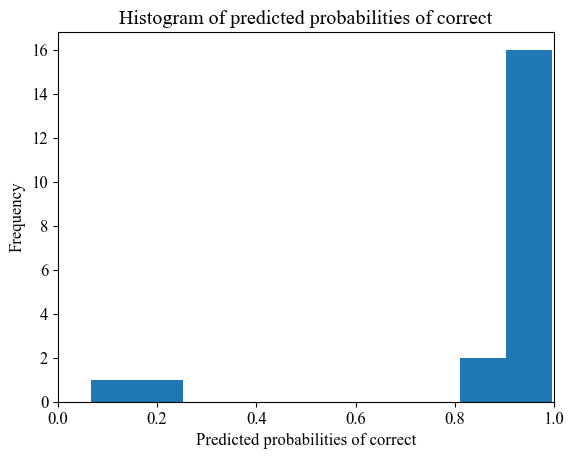

In [113]:
# plot histogram of predicted probabilities


# adjust the font size 
plt.rcParams['font.size'] = 12


# plot histogram with 10 bins
plt.hist(y_pred1, bins = 10)


# set the title of predicted probabilities
plt.title('Histogram of predicted probabilities of correct')


# set the x-axis limit
plt.xlim(0,1)


# set the title
plt.xlabel('Predicted probabilities of correct')
plt.ylabel('Frequency')

### ROC - AUC
Another tool to measure the classification model performance visually is ROC Curve. ROC Curve stands for Receiver Operating Characteristic Curve. An ROC Curve is a plot which shows the performance of a classification model at various classification threshold levels.

The ROC Curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold levels.

True Positive Rate (TPR) is also called Recall. It is defined as the ratio of TP to (TP + FN).

False Positive Rate (FPR) is defined as the ratio of FP to (FP + TN).

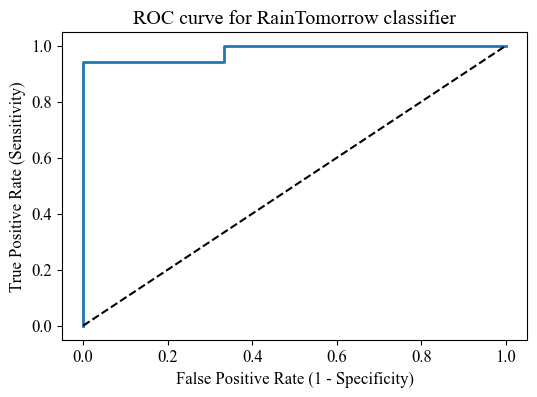

In [116]:
# plot ROC Curve

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred1)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], 'k--' )
plt.rcParams['font.size'] = 12
plt.title('ROC curve for RainTomorrow classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.show()

In [118]:
# compute ROC AUC

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_test, y_pred1)
print('ROC AUC : {:.4f}'.format(ROC_AUC))

ROC AUC : 0.9804


ROC AUC is a single number summary of classifier performance. The higher the value, the better the classifier.

ROC AUC of our model approaches towards 1. So, we can conclude that our classifier does a good job in predicting whether it will rain tomorrow or not.

In [121]:
# calculate cross-validated ROC AUC 

from sklearn.model_selection import cross_val_score

Cross_validated_ROC_AUC = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='roc_auc').mean()

print('Cross validated ROC AUC : {:.4f}'.format(Cross_validated_ROC_AUC))

Cross validated ROC AUC : 0.9375


### Threshold

In [124]:
# Find the optimal threshold using Logistic regression and Younden's J Statistics
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]
optimal_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal Threshold for com_score based on Logistic Regression: {optimal_threshold:.2f}")

Optimal Threshold for com_score based on Logistic Regression: 0.93


In [130]:
# Find the corresponding com_score threshold value
threshold_value = X_test[y_pred_proba >= optimal_threshold].median() # Using mean or min function to extract the corresponing threshold value
print(f"Corresponding com_score value for the optimal threshold: {threshold_value.iloc[0]:.2f}")

Corresponding com_score value for the optimal threshold: 96.56


### Explanation of using this methodology

### 1. Why Use Logistic Regression?
#### Context & Justification
The goal is to classify observations into two classes:
Correct Identification (1) = Both iMap and iNat correct.
Incorrect Identification (0) = Any other category.
    
Logistic regression is appropriate for binary classification problems because:
It models the probability that an observation belongs to class 1 (correct identification).
It provides probability scores, which can be thresholded to optimize classification performance.

### 2. Why Use Youden’s J Statistic for Optimal Threshold Selection?
#### Context & Justification
Logistic regression provides probability scores, but we need to determine a decision threshold to classify observations.
The default threshold is 0.5, but this is not necessarily optimal in real-world classification tasks.
Youden’s J Statistic identifies the threshold that maximizes the trade-off between sensitivity and specificity.
Mathematical Justification

J=Sensitivity−(1 - Specificity)

where:

Sensitivity (True Positive Rate, TPR) = proportion of correctly classified positives.

Specificity (True Negative Rate, 1 - False Positive Rate, FPR) = proportion of correctly classified negatives.

#### Critical Interpretation
The optimal threshold is selected from the ROC curve where J is maximized.
The corresponding minimum com_score value at this threshold is also identified.

### Threshold for all 11 species

Beach leaf disease nematode (Litylenchus crenatae mccannii): 85.69 

Common buckthorn (Rhamnus cathartica): 81.5

Garlic mustard (Alliaria petiolata): 88.91

Hemlock Woolly Adelgid (Adelges tsugae): 82.85

Japanese Knotweed (Reynoutria japonica): 76.73

Japanese Barberry (Berberis thunbergii): 90.06

Multiflora Rose (Rosa multiflora): 74.05

Oriental Bittersweet (Celastrus orbiculatus): 65.45

Purple Loosestrife (Lythrum salicaria): 89.08

Spotted Lanternfly (Lycorma delicatula): 92.79

Tree-of-heaven (Ailanthus altissima): 87.09

Combined threshold value for 11 species: 77.62

### Mean Geo_score for all 11 species

Beach leaf disease nematode (Litylenchus crenatae mccannii): 21.54 

Common buckthorn (Rhamnus cathartica): 31.47

Garlic mustard (Alliaria petiolata): 39.89

Hemlock Woolly Adelgid (Adelges tsugae): 21.26

Japanese Knotweed (Reynoutria japonica): 31.94

Japanese Barberry (Berberis thunbergii): 36.55

Multiflora Rose (Rosa multiflora): 41.31

Oriental Bittersweet (Celastrus orbiculatus): 33.65

Purple Loosestrife (Lythrum salicaria): 38.21

Spotted Lanternfly (Lycorma delicatula): 72.02

Tree-of-heaven (Ailanthus altissima): 32.68

Combined threshold value for 11 species: 36.5

### Evaluation of classification metrics

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv("Threshold and accuracy values.csv")

# Set species name as the index for better visualization
df = df.set_index("Name of species")

# Convert Best Accuracy to Percentage
df["Best accuracy"] = df["Best accuracy"] * 100  # Convert to percentage

# Define key columns for visualization
selected_columns = ["Threshold", "Mean com score", "Mean at label 1", "Mean at label 0", "Standard deviation", "Mean geo score", "Best accuracy"]


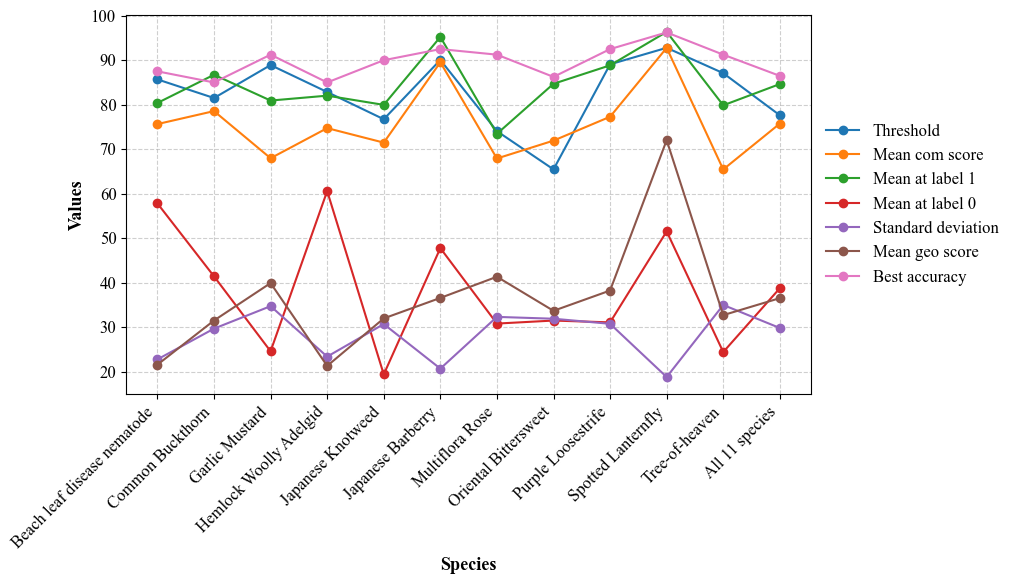

In [141]:
# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'


# 1. Line Plot: Trends of Key Metrics Across Species
plt.figure(figsize=(12, 6))

for col in selected_columns:
    plt.plot(df.index, df[col], marker='o', label=col)

# Titles and labels
plt.xlabel("Species", fontsize=13, fontweight='bold')
plt.ylabel("Values", fontsize=13, fontweight='bold')

# Rotate x-tick labels
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

# Add legend outside the plot on the right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=12)

# Add grid
plt.grid(True, linestyle="--", alpha=0.6)

# Adjust layout to make room for legend
plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space on right for legend

# Save figure
output_file = os.path.join(output_path, "Line plot for trend of key metrics across species.png")
plt.savefig(output_file, dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

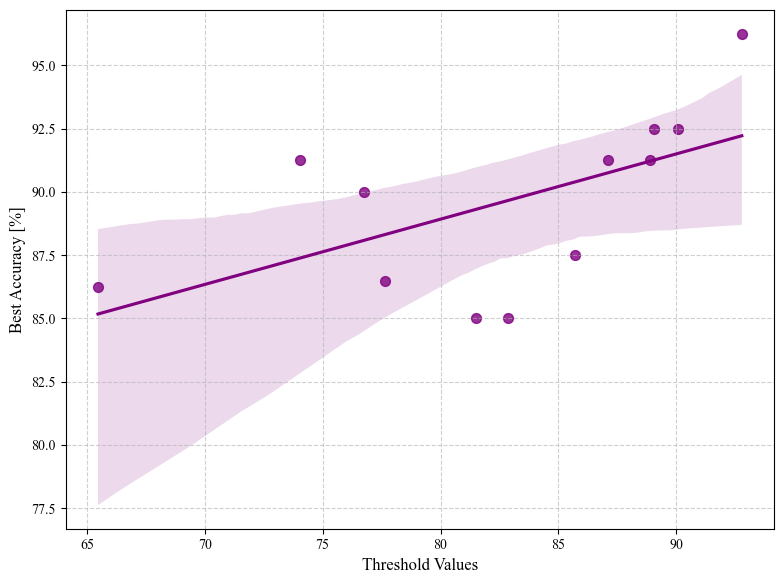

In [143]:
# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# 2. Scatter Plot with Regression Line (for Accuracy vs Threshold)
plt.figure(figsize=(8, 6))

sns.regplot(
    x=df["Threshold"],
    y=df["Best accuracy"],
    scatter_kws={"s": 50},
    color="purple"
)

# Labels with Times New Roman and consistent font size
plt.xlabel("Threshold Values", fontsize=12)
plt.ylabel("Best Accuracy [%]", fontsize=12)

# Customize tick label font sizes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Optional title
# plt.title("Threshold Values vs Best Accuracy (%)", fontsize=14)

# Grid and layout adjustments
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# Save figure (optional)
output_file = os.path.join(output_path, "Scatter threshold vs accuracy.png")
plt.savefig(output_file, dpi=300, bbox_inches="tight")

plt.show()